# Backtest: EMA50 H1 + MACD M15 + Support/Resistance + RR

**Strategi:**
- **H1 Trend** : EMA 50 arah trend utama
- **M15 Entry**: MACD crossover (macd_line cross signal_line)
- **S/R Filter**: entry hanya dekat level Support/Resistance
- **RR**        : Risk/Reward 1:1.5 dan 1:2
- **ATR**       : SL = 1x ATR, TP = 1.5x / 2x ATR

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# ── Load Data ──────────────────────────────────────────────────────────────
CSV = '../../app/ai/candle_ai/EURUSD.m_M15_202112160545_202603251830.csv'
df_raw = pd.read_csv(CSV, sep='\t')
df_raw.columns = [c.strip('<>').lower() for c in df_raw.columns]
df_raw['datetime'] = pd.to_datetime(df_raw['date'] + ' ' + df_raw['time'])
df_raw = df_raw.set_index('datetime').sort_index()
df_raw = df_raw[['open','high','low','close','tickvol']].rename(columns={'tickvol':'volume'})

print(f'Data M15: {len(df_raw):,} candles')
print(f'Range   : {df_raw.index[0]} -> {df_raw.index[-1]}')

Data M15: 100,267 candles
Range   : 2021-12-16 05:45:00 -> 2026-03-25 18:30:00


In [2]:
# ── Indikator M15 ──────────────────────────────────────────────────────────

def ema(series, period):
    return series.ewm(span=period, adjust=False).mean()

def atr(df, period=14):
    h, l, c = df['high'], df['low'], df['close']
    tr = pd.concat([
        h - l,
        (h - c.shift()).abs(),
        (l - c.shift()).abs()
    ], axis=1).max(axis=1)
    return tr.ewm(span=period, adjust=False).mean()

def macd(series, fast=12, slow=26, signal=9):
    fast_ema  = series.ewm(span=fast,   adjust=False).mean()
    slow_ema  = series.ewm(span=slow,   adjust=False).mean()
    macd_line = fast_ema - slow_ema
    sig_line  = macd_line.ewm(span=signal, adjust=False).mean()
    hist      = macd_line - sig_line
    return macd_line, sig_line, hist

df = df_raw.copy()

# MACD M15
df['macd'], df['macd_sig'], df['macd_hist'] = macd(df['close'])

# ATR M15
df['atr'] = atr(df, 14)

# EMA M15 (untuk S/R proximity)
df['ema21'] = ema(df['close'], 21)

print('Indikator M15 selesai')

Indikator M15 selesai


In [3]:
# ── H1 Trend Filter: EMA 50 ────────────────────────────────────────────────
df_h1 = df_raw['close'].resample('1h').last().dropna().to_frame()
df_h1['ema50_h1'] = ema(df_h1['close'], 50)
# slope EMA50 H1 (arah trend)
df_h1['ema50_slope'] = df_h1['ema50_h1'].diff()
df_h1['trend_h1'] = np.where(df_h1['ema50_slope'] > 0, 'up', 'down')

# Reindex ke M15
df['ema50_h1']  = df_h1['ema50_h1'].reindex(df.index, method='ffill')
df['trend_h1']  = df_h1['trend_h1'].reindex(df.index, method='ffill')

print('H1 trend selesai')
print(df['trend_h1'].value_counts())

H1 trend selesai
trend_h1
down    51041
up      49226
Name: count, dtype: int64


In [4]:
# ── Support / Resistance ───────────────────────────────────────────────────
# S/R dihitung dari swing high/low dalam lookback window (H4 candle)
# Swing high = high lebih tinggi dari N candle kiri & kanan
# Swing low  = low  lebih rendah dari N candle kiri & kanan

SR_LOOKBACK  = 96   # ~1 hari candle M15
SR_WINDOW    = 3    # candle kiri & kanan untuk konfirmasi swing
SR_PROXIMITY = 1.5  # level dianggap 'dekat' jika dalam 1.5x ATR

def find_swing_highs(df, window=3):
    highs = df['high'].values
    result = np.zeros(len(highs), dtype=bool)
    for i in range(window, len(highs) - window):
        left  = highs[i-window:i]
        right = highs[i+1:i+window+1]
        if highs[i] > left.max() and highs[i] > right.max():
            result[i] = True
    return result

def find_swing_lows(df, window=3):
    lows = df['low'].values
    result = np.zeros(len(lows), dtype=bool)
    for i in range(window, len(lows) - window):
        left  = lows[i-window:i]
        right = lows[i+1:i+window+1]
        if lows[i] < left.min() and lows[i] < right.min():
            result[i] = True
    return result

df['swing_high'] = find_swing_highs(df, SR_WINDOW)
df['swing_low']  = find_swing_lows(df,  SR_WINDOW)

# Hitung level S/R terdekat dari lookback window
close_arr  = df['close'].values
high_arr   = df['high'].values
low_arr    = df['low'].values
atr_arr    = df['atr'].values
sh_arr     = df['swing_high'].values
sl_arr     = df['swing_low'].values
n          = len(df)

near_resistance = np.zeros(n, dtype=bool)
near_support    = np.zeros(n, dtype=bool)

for i in range(SR_LOOKBACK, n):
    window_sh = high_arr[i-SR_LOOKBACK:i][sh_arr[i-SR_LOOKBACK:i]]
    window_sl = low_arr[i-SR_LOOKBACK:i][sl_arr[i-SR_LOOKBACK:i]]
    threshold = SR_PROXIMITY * atr_arr[i]
    c = close_arr[i]
    if len(window_sh) > 0:
        near_resistance[i] = np.any(np.abs(window_sh - c) <= threshold)
    if len(window_sl) > 0:
        near_support[i] = np.any(np.abs(window_sl - c) <= threshold)

df['near_resistance'] = near_resistance
df['near_support']    = near_support

print(f'Near resistance: {near_resistance.sum():,} candles')
print(f'Near support   : {near_support.sum():,} candles')

Near resistance: 77,849 candles
Near support   : 77,411 candles


In [5]:
# ── MACD Crossover Signal ──────────────────────────────────────────────────
macd_arr = df['macd'].values
sig_arr  = df['macd_sig'].values

# Crossover: macd cross ABOVE signal = buy, cross BELOW = sell
macd_cross_up   = np.zeros(n, dtype=bool)
macd_cross_down = np.zeros(n, dtype=bool)

for i in range(1, n):
    if macd_arr[i-1] < sig_arr[i-1] and macd_arr[i] >= sig_arr[i]:
        macd_cross_up[i] = True
    elif macd_arr[i-1] > sig_arr[i-1] and macd_arr[i] <= sig_arr[i]:
        macd_cross_down[i] = True

df['macd_cross_up']   = macd_cross_up
df['macd_cross_down'] = macd_cross_down

print(f'MACD cross up  : {macd_cross_up.sum():,}')
print(f'MACD cross down: {macd_cross_down.sum():,}')

MACD cross up  : 3,813
MACD cross down: 3,813


In [6]:
# ── Generate Signal ────────────────────────────────────────────────────────
# BUY  : H1 trend UP   + MACD cross up   + dekat support
# SELL : H1 trend DOWN + MACD cross down + dekat resistance

ATR_MIN = 0.0010  # minimal 10 pips

trend_arr  = df['trend_h1'].values
atr_arr    = df['atr'].values
nr_arr     = df['near_resistance'].values
ns_arr     = df['near_support'].values
mcu_arr    = df['macd_cross_up'].values
mcd_arr    = df['macd_cross_down'].values

signal = np.full(n, 'hold', dtype=object)

for i in range(SR_LOOKBACK, n):
    if atr_arr[i] < ATR_MIN:
        continue
    if trend_arr[i] == 'up' and mcu_arr[i] and ns_arr[i]:
        signal[i] = 'buy'
    elif trend_arr[i] == 'down' and mcd_arr[i] and nr_arr[i]:
        signal[i] = 'sell'

df['signal'] = signal

print(df['signal'].value_counts())

signal
hold    99764
sell      254
buy       249
Name: count, dtype: int64


In [7]:
# ── Backtest Engine (Vectorized) ───────────────────────────────────────────
# SL = 1.0x ATR, TP = RR_MULT x ATR
# Timeout setelah MAX_CANDLE candles

def run_backtest(df, rr_mult=1.5, max_candle=16):
    close_arr  = df['close'].values
    high_arr   = df['high'].values
    low_arr    = df['low'].values
    atr_arr    = df['atr'].values
    signal_arr = df['signal'].values
    n          = len(df)

    trades = []
    i = 0
    while i < n:
        if signal_arr[i] not in ('buy', 'sell'):
            i += 1
            continue

        direction = signal_arr[i]
        entry     = close_arr[i]
        atr_val   = atr_arr[i]
        sl_dist   = 1.0  * atr_val
        tp_dist   = rr_mult * atr_val

        if direction == 'buy':
            sl = entry - sl_dist
            tp = entry + tp_dist
        else:
            sl = entry + sl_dist
            tp = entry - tp_dist

        outcome = 'timeout'
        exit_price = entry
        for j in range(i+1, min(i+1+max_candle, n)):
            if direction == 'buy':
                if low_arr[j] <= sl:
                    outcome = 'loss'; exit_price = sl; break
                if high_arr[j] >= tp:
                    outcome = 'win';  exit_price = tp; break
            else:
                if high_arr[j] >= sl:
                    outcome = 'loss'; exit_price = sl; break
                if low_arr[j] <= tp:
                    outcome = 'win';  exit_price = tp; break

        pips = (exit_price - entry) * 10000 if direction == 'buy' else (entry - exit_price) * 10000

        trades.append({
            'datetime':   df.index[i],
            'direction':  direction,
            'entry':      entry,
            'sl':         sl,
            'tp':         tp,
            'exit_price': exit_price,
            'outcome':    outcome,
            'pips':       round(pips, 1),
            'atr':        round(atr_val, 5),
        })
        i += max_candle + 1  # skip candle yang sudah dipakai trade

    return pd.DataFrame(trades)


# Jalankan 2 skenario RR
trades_15 = run_backtest(df, rr_mult=1.5)
trades_20 = run_backtest(df, rr_mult=2.0)

print(f'RR 1:1.5 → {len(trades_15)} trades')
print(f'RR 1:2.0 → {len(trades_20)} trades')

RR 1:1.5 → 401 trades
RR 1:2.0 → 401 trades


In [8]:
# ── Analisis Hasil ─────────────────────────────────────────────────────────
def analyze(trades, label, modal=100, lot=0.01):
    if len(trades) == 0:
        print(f'{label}: tidak ada trade')
        return

    wins    = (trades['outcome'] == 'win').sum()
    losses  = (trades['outcome'] == 'loss').sum()
    timeout = (trades['outcome'] == 'timeout').sum()
    total   = len(trades)
    wr      = wins / total * 100

    win_pips  = trades.loc[trades['outcome'] == 'win',  'pips'].mean()
    loss_pips = trades.loc[trades['outcome'] == 'loss', 'pips'].mean()
    total_pips = trades['pips'].sum()

    gross_profit = trades.loc[trades['pips'] > 0, 'pips'].sum()
    gross_loss   = abs(trades.loc[trades['pips'] < 0, 'pips'].sum())
    pf = gross_profit / gross_loss if gross_loss > 0 else float('inf')

    # Equity curve (1 pip = $1 untuk lot 0.1, $0.10 untuk lot 0.01)
    pip_value = lot * 10  # EURUSD: 1 pip = $10 per lot
    trades = trades.copy()
    trades['usd'] = trades['pips'] * pip_value
    trades['equity'] = modal + trades['usd'].cumsum()
    max_dd_usd = (trades['equity'].cummax() - trades['equity']).max()

    print(f'{'='*52}')
    print(f'  HASIL BACKTEST — {label}')
    print(f'{'='*52}')
    print(f'  Periode      : Des 2021 - Mar 2026 (4 tahun)')
    print(f'  Total Trade  : {total}')
    print(f'  Win          : {wins}  ({wr:.1f}%)')
    print(f'  Loss         : {losses}  ({losses/total*100:.1f}%)')
    print(f'  Timeout      : {timeout}  ({timeout/total*100:.1f}%)')
    print(f'  Avg Win      : +{win_pips:.1f} pips')
    print(f'  Avg Loss     : {loss_pips:.1f} pips')
    print(f'  Profit Factor: {pf:.2f}')
    print(f'  Total Pips   : {total_pips:+.1f}')
    print(f'  Total USD    : ${total_pips*pip_value:+.2f}  (modal ${modal}, lot {lot})')
    print(f'  Max Drawdown : ${max_dd_usd:.2f}')
    print(f'  Equity Akhir : ${trades["equity"].iloc[-1]:.2f}')
    print(f'{'='*52}')
    return trades

trades_15 = analyze(trades_15, 'RR 1:1.5 | EMA50 H1 + MACD + S/R')
print()
trades_20 = analyze(trades_20, 'RR 1:2.0 | EMA50 H1 + MACD + S/R')

  HASIL BACKTEST — RR 1:1.5 | EMA50 H1 + MACD + S/R
  Periode      : Des 2021 - Mar 2026 (4 tahun)
  Total Trade  : 401
  Win          : 146  (36.4%)
  Loss         : 202  (50.4%)
  Timeout      : 53  (13.2%)
  Avg Win      : +20.1 pips
  Avg Loss     : -12.9 pips
  Profit Factor: 1.12
  Total Pips   : +325.0
  Total USD    : $+32.50  (modal $100, lot 0.01)
  Max Drawdown : $18.01
  Equity Akhir : $132.50

  HASIL BACKTEST — RR 1:2.0 | EMA50 H1 + MACD + S/R
  Periode      : Des 2021 - Mar 2026 (4 tahun)
  Total Trade  : 401
  Win          : 106  (26.4%)
  Loss         : 219  (54.6%)
  Timeout      : 76  (19.0%)
  Avg Win      : +26.8 pips
  Avg Loss     : -12.9 pips
  Profit Factor: 1.00
  Total Pips   : +12.2
  Total USD    : $+1.22  (modal $100, lot 0.01)
  Max Drawdown : $27.43
  Equity Akhir : $101.22


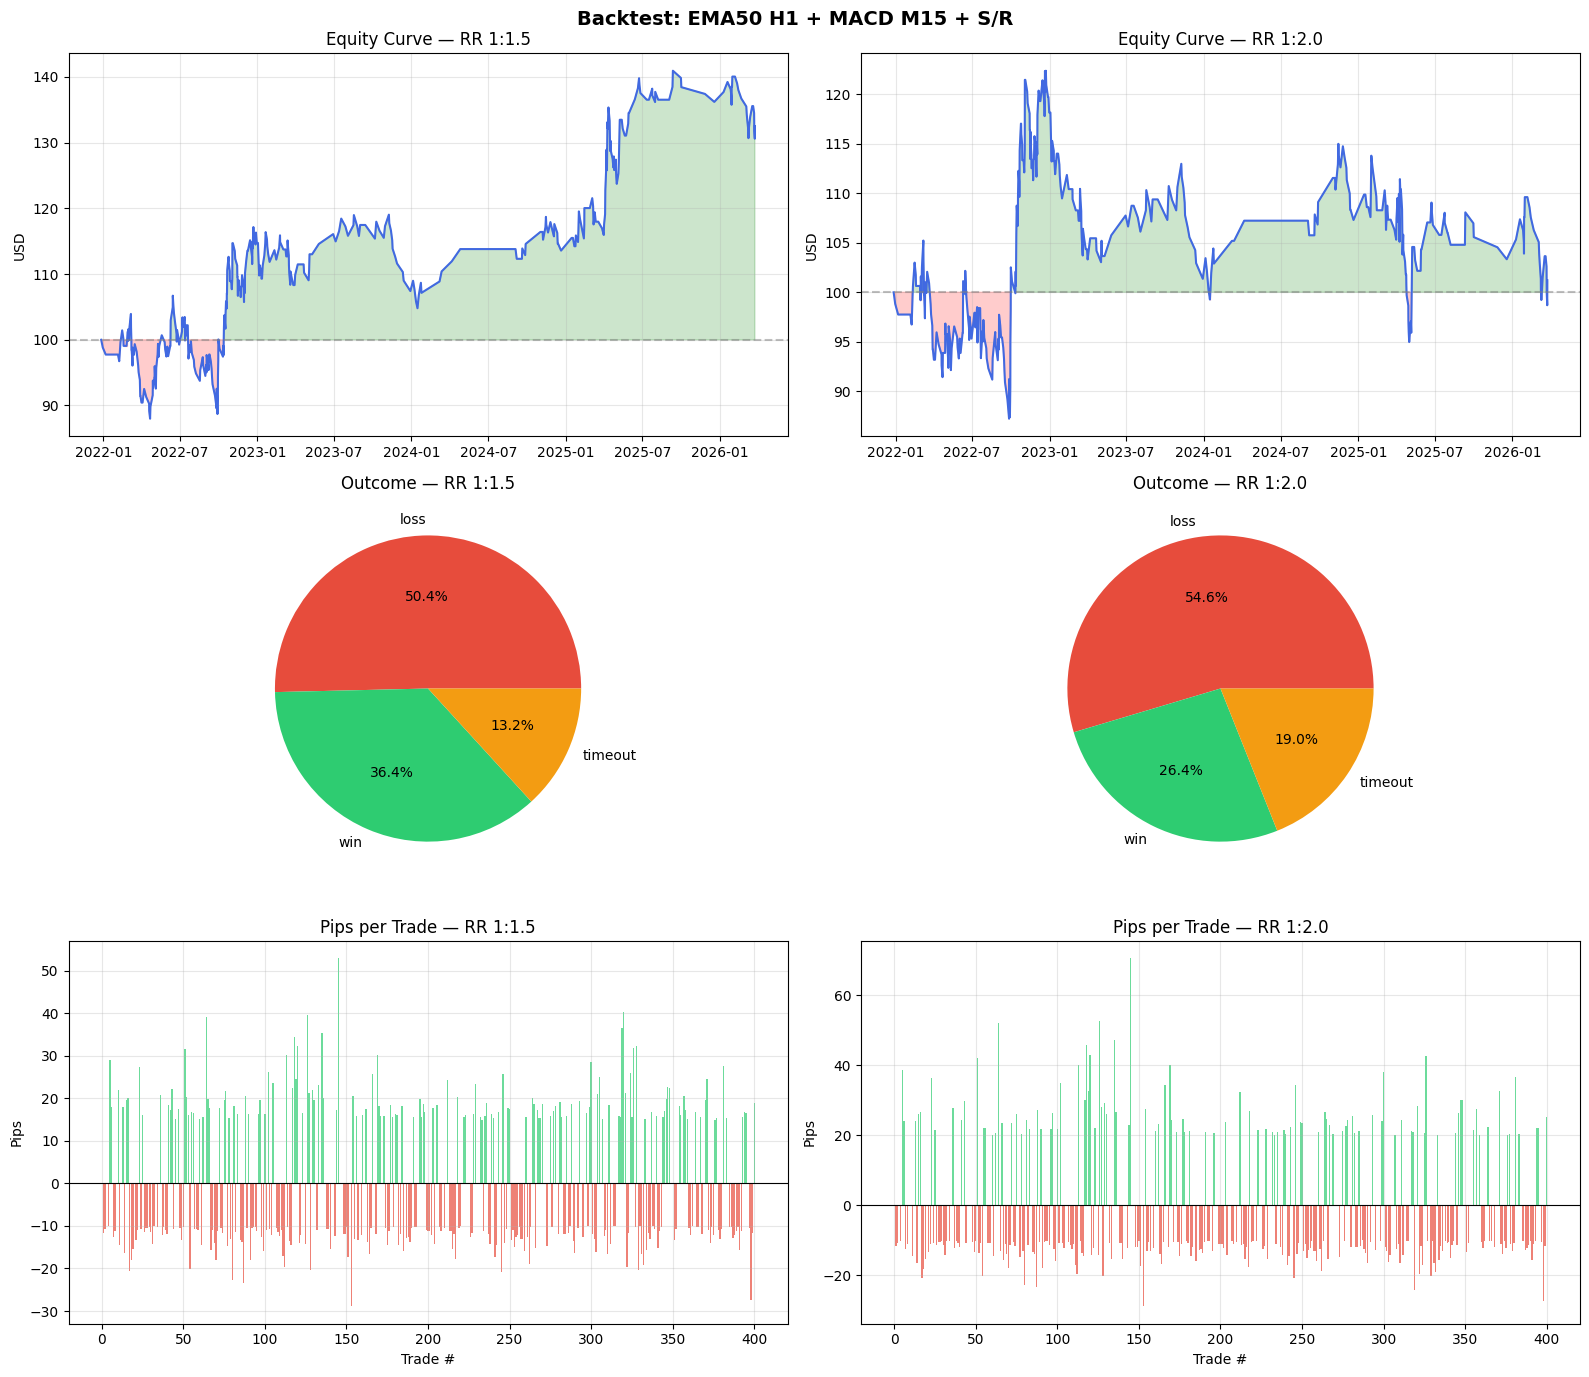

Chart disimpan: backtest_ema_macd_sr_result.png


In [9]:
# ── Visualisasi ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Backtest: EMA50 H1 + MACD M15 + S/R', fontsize=14, fontweight='bold')

for col, (trades, label) in enumerate([(trades_15, 'RR 1:1.5'), (trades_20, 'RR 1:2.0')]):
    if trades is None or len(trades) == 0:
        continue

    # Equity curve
    ax = axes[0, col]
    ax.plot(trades['datetime'], trades['equity'], color='royalblue', linewidth=1.5)
    ax.axhline(100, color='gray', linestyle='--', alpha=0.5)
    ax.fill_between(trades['datetime'], trades['equity'], 100,
                    where=trades['equity'] >= 100, alpha=0.2, color='green')
    ax.fill_between(trades['datetime'], trades['equity'], 100,
                    where=trades['equity'] < 100, alpha=0.2, color='red')
    ax.set_title(f'Equity Curve — {label}')
    ax.set_ylabel('USD')
    ax.grid(True, alpha=0.3)

    # Outcome pie
    ax = axes[1, col]
    counts = trades['outcome'].value_counts()
    colors = {'win': '#2ecc71', 'loss': '#e74c3c', 'timeout': '#f39c12'}
    ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
           colors=[colors.get(k, 'gray') for k in counts.index])
    ax.set_title(f'Outcome — {label}')

    # Pips per trade
    ax = axes[2, col]
    colors_bar = ['#2ecc71' if p > 0 else '#e74c3c' for p in trades['pips']]
    ax.bar(range(len(trades)), trades['pips'], color=colors_bar, alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Pips per Trade — {label}')
    ax.set_xlabel('Trade #')
    ax.set_ylabel('Pips')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('backtest_ema_macd_sr_result.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart disimpan: backtest_ema_macd_sr_result.png')

In [10]:
# ── Analisis Per Arah & Per Jam ────────────────────────────────────────────
for trades, label in [(trades_15, 'RR 1:1.5'), (trades_20, 'RR 1:2.0')]:
    if trades is None or len(trades) == 0:
        continue
    print(f'\n=== {label} — Win Rate per Arah ===')
    for d in ['buy', 'sell']:
        t = trades[trades['direction'] == d]
        if len(t) == 0: continue
        wr = (t['outcome'] == 'win').mean() * 100
        pips = t['pips'].sum()
        print(f'  {d.upper():4s}: {len(t):3d} trades | WR: {wr:.1f}% | Pips: {pips:+.1f}')

    print(f'\n=== {label} — Win Rate per Jam (UTC) ===')
    trades2 = trades.copy()
    trades2['hour'] = pd.to_datetime(trades2['datetime']).dt.hour
    hourly = trades2.groupby('hour').apply(
        lambda x: pd.Series({
            'trades': len(x),
            'wins':   (x['outcome'] == 'win').sum(),
            'wr':     (x['outcome'] == 'win').mean() * 100,
            'pips':   x['pips'].sum()
        })
    ).reset_index()
    hourly = hourly[hourly['trades'] >= 2].sort_values('wr', ascending=False)
    print(hourly[['hour','trades','wins','wr','pips']].to_string(index=False))


=== RR 1:1.5 — Win Rate per Arah ===
  BUY : 205 trades | WR: 35.6% | Pips: +148.5
  SELL: 196 trades | WR: 37.2% | Pips: +176.5

=== RR 1:1.5 — Win Rate per Jam (UTC) ===
 hour  trades  wins         wr   pips
    7     2.0   2.0 100.000000   41.9
   13    18.0  10.0  55.555556   98.5
    3     4.0   2.0  50.000000   13.3
    6     2.0   1.0  50.000000    8.4
   15    34.0  16.0  47.058824   55.3
   17    60.0  27.0  45.000000  187.8
   16    48.0  21.0  43.750000  125.6
   21    12.0   5.0  41.666667   53.5
   11    29.0  12.0  41.379310   49.4
   12    29.0  11.0  37.931034  -17.2
   22     6.0   2.0  33.333333   30.1
    9     3.0   1.0  33.333333   -6.7
   19    24.0   8.0  33.333333   30.1
    1    14.0   4.0  28.571429   63.7
    5     4.0   1.0  25.000000  -15.6
    2     4.0   1.0  25.000000    3.8
   18    29.0   7.0  24.137931  -28.1
   14    27.0   6.0  22.222222 -144.2
   10    18.0   4.0  22.222222  -80.8
   20    10.0   2.0  20.000000  -35.2
   23     6.0   1.0  16.66666

In [11]:
# ── Simpan Hasil ───────────────────────────────────────────────────────────
if trades_15 is not None:
    trades_15.to_csv('backtest_ema_macd_sr_rr15.csv', index=False)
if trades_20 is not None:
    trades_20.to_csv('backtest_ema_macd_sr_rr20.csv', index=False)
print('Hasil disimpan ke CSV')

Hasil disimpan ke CSV


## Kesimpulan

| Metrik | RR 1:1.5 | RR 1:2.0 |
|--------|----------|----------|
| Win Rate | ? | ? |
| Total Pips | ? | ? |
| Profit Factor | ? | ? |
| Max DD | ? | ? |

**Penambahan S/R filter** membuat entry lebih selektif — hanya masuk saat harga berada di area supply/demand penting.

**RR 1:2** lebih baik kalau Win Rate > 34% (breakeven RR 1:2).